In [1]:
import tensorflow_datasets as tfds
from datetime import datetime
#!pip install tensorflow_datasets
#!pip install tensorflow-text
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
print(tf.__version__)

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



2.15.0


 # Construir pipelines en TensorFlow 

## La API tf.data.Dataset admite la escritura  descriptivas y pipelines eficientes. El uso del conjunto de datos sigue:

* Creacion de un conjunto de datos original a partir de sus datos de entrada.
* Aplicar transformaciones de conjuntos de datos para preprocesar los datos.
* Iterar sobre el conjunto de datos y procesar los elementos.
La iteración ocurre tipo streaming por lo que no es necesario que el conjunto de datos completo quepa en la memoria.

para construir un conjunto de datos a partir de datos en la memoria, puede usar:
* tf.data.Dataset.from_tensors()
* tf.data.Dataset.from_tensor_slices()
* tf.data.TFRecordDataset() 


### Lista de python

In [2]:
array_examp =np.array(range(70)).reshape(7,10)
lista_examp = array_examp.tolist()
print(array_examp.shape)

(7, 10)


In [3]:
lista_examp

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
 [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
 [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
 [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
 [60, 61, 62, 63, 64, 65, 66, 67, 68, 69]]

In [4]:
array_examp

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
       [60, 61, 62, 63, 64, 65, 66, 67, 68, 69]])

In [5]:
dataset1 = tf.data.Dataset.from_tensor_slices(array_examp)
dataset2 = tf.data.Dataset.from_tensors(array_examp)
dataset_lista_1 = tf.data.Dataset.from_tensor_slices(lista_examp)
dataset_lista_2 = tf.data.Dataset.from_tensors(lista_examp)

In [6]:
tf.data.Dataset.from_tensor_slices(array_examp).element_spec

TensorSpec(shape=(10,), dtype=tf.int32, name=None)

In [7]:
tf.data.Dataset.from_tensors(array_examp).element_spec

TensorSpec(shape=(7, 10), dtype=tf.int32, name=None)

In [8]:
print(dataset1.element_spec)
print(dataset2.element_spec)
print(dataset_lista_1.element_spec)
print(dataset_lista_2.element_spec)

TensorSpec(shape=(10,), dtype=tf.int32, name=None)
TensorSpec(shape=(7, 10), dtype=tf.int32, name=None)
TensorSpec(shape=(10,), dtype=tf.int32, name=None)
TensorSpec(shape=(7, 10), dtype=tf.int32, name=None)


In [9]:
tensor1 = tf.ones([10,2,2])
tensor2 = tf.ones([10,1])
tensor3 = tf.ones([9,2,2])

In [10]:
dataset3 = tf.data.Dataset.from_tensor_slices((tensor1, tensor2))
dataset3

<_TensorSliceDataset element_spec=(TensorSpec(shape=(2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>

In [11]:
dataset4 = tf.data.Dataset.from_tensor_slices((tensor1, tensor3))

ValueError: Dimensions 10 and 9 are not compatible

In [12]:
dataset5 = tf.data.Dataset.from_tensors((tensor1, tensor2))
dataset6 = tf.data.Dataset.from_tensors((tensor1, tensor3))
dataset6

<_TensorDataset element_spec=(TensorSpec(shape=(10, 2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(9, 2, 2), dtype=tf.float32, name=None))>

In [13]:
print(dataset3.element_spec)
print(dataset5.element_spec)
print(dataset6.element_spec)

(TensorSpec(shape=(2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))
(TensorSpec(shape=(10, 2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(10, 1), dtype=tf.float32, name=None))
(TensorSpec(shape=(10, 2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(9, 2, 2), dtype=tf.float32, name=None))


In [14]:
dataset2

<_TensorDataset element_spec=TensorSpec(shape=(7, 10), dtype=tf.int32, name=None)>

In [15]:
dataset3 = tf.data.Dataset.zip((dataset1, dataset2))
#print(dataset3.element_spec)
for a, b in dataset3:
      print('shapes: {a.shape}, {b.shape}'.format(a=a, b=b))


shapes: (10,), (7, 10)


### Iteracion

In [16]:
dataset1

<_TensorSliceDataset element_spec=TensorSpec(shape=(10,), dtype=tf.int32, name=None)>

In [17]:
for elem in dataset1:
  print(elem.numpy())
  

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]
[20 21 22 23 24 25 26 27 28 29]
[30 31 32 33 34 35 36 37 38 39]
[40 41 42 43 44 45 46 47 48 49]
[50 51 52 53 54 55 56 57 58 59]
[60 61 62 63 64 65 66 67 68 69]


### Enumerar

In [18]:
dataset_enu = dataset1.enumerate(start=0)
for element in dataset_enu.as_numpy_iterator():
  print(element)

(0, array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))
(1, array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19]))
(2, array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29]))
(3, array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39]))
(4, array([40, 41, 42, 43, 44, 45, 46, 47, 48, 49]))
(5, array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59]))
(6, array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69]))


### Barajar

In [19]:
len(dataset1)

7

In [20]:
dataset_shu = dataset1.shuffle(len(dataset1), reshuffle_each_iteration=True)
dataset_shu=dataset_shu.repeat(count=4) ## si count =-1 => se repite indefinidamente 
for element in dataset_shu.as_numpy_iterator():
  print(element)

[30 31 32 33 34 35 36 37 38 39]
[60 61 62 63 64 65 66 67 68 69]
[40 41 42 43 44 45 46 47 48 49]
[10 11 12 13 14 15 16 17 18 19]
[0 1 2 3 4 5 6 7 8 9]
[20 21 22 23 24 25 26 27 28 29]
[50 51 52 53 54 55 56 57 58 59]
[10 11 12 13 14 15 16 17 18 19]
[40 41 42 43 44 45 46 47 48 49]
[60 61 62 63 64 65 66 67 68 69]
[50 51 52 53 54 55 56 57 58 59]
[0 1 2 3 4 5 6 7 8 9]
[30 31 32 33 34 35 36 37 38 39]
[20 21 22 23 24 25 26 27 28 29]
[60 61 62 63 64 65 66 67 68 69]
[50 51 52 53 54 55 56 57 58 59]
[10 11 12 13 14 15 16 17 18 19]
[20 21 22 23 24 25 26 27 28 29]
[30 31 32 33 34 35 36 37 38 39]
[40 41 42 43 44 45 46 47 48 49]
[0 1 2 3 4 5 6 7 8 9]
[30 31 32 33 34 35 36 37 38 39]
[10 11 12 13 14 15 16 17 18 19]
[60 61 62 63 64 65 66 67 68 69]
[50 51 52 53 54 55 56 57 58 59]
[20 21 22 23 24 25 26 27 28 29]
[40 41 42 43 44 45 46 47 48 49]
[0 1 2 3 4 5 6 7 8 9]


### Batch

In [21]:
dataset_range = tf.data.Dataset.range(20).batch(3) #[0,1,2,...19]
dataset_range

<_BatchDataset element_spec=TensorSpec(shape=(None,), dtype=tf.int64, name=None)>

In [22]:
dataset_range = tf.data.Dataset.range(20) #[0,1,2,...19]
dataset_range = dataset_range.batch(3)
dataset_range = dataset_range.enumerate(start=0)
for element in dataset_range.as_numpy_iterator():
  print(element)

(0, array([0, 1, 2], dtype=int64))
(1, array([3, 4, 5], dtype=int64))
(2, array([6, 7, 8], dtype=int64))
(3, array([ 9, 10, 11], dtype=int64))
(4, array([12, 13, 14], dtype=int64))
(5, array([15, 16, 17], dtype=int64))
(6, array([18, 19], dtype=int64))


In [23]:
dataset_range = tf.data.Dataset.range(20) #[0,1,2,...19]
dataset_range = dataset_range.batch(3,drop_remainder=True)
dataset_range = dataset_range.enumerate(start=0)
for element in dataset_range.as_numpy_iterator():
  print(element)

(0, array([0, 1, 2], dtype=int64))
(1, array([3, 4, 5], dtype=int64))
(2, array([6, 7, 8], dtype=int64))
(3, array([ 9, 10, 11], dtype=int64))
(4, array([12, 13, 14], dtype=int64))
(5, array([15, 16, 17], dtype=int64))


In [24]:
dataset_range

<_ZipDataset element_spec=(TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(3,), dtype=tf.int64, name=None))>

In [25]:
for element in dataset_range.take(3):   ##Take()
  print(element[0].numpy(),element[1].numpy())

0 [0 1 2]
1 [3 4 5]
2 [6 7 8]


In [26]:
dataset1

<_TensorSliceDataset element_spec=TensorSpec(shape=(10,), dtype=tf.int32, name=None)>

In [27]:
dataset1_range = dataset1.batch(3)
dataset1_range = dataset1_range.enumerate(start=0)
for element in dataset1_range.as_numpy_iterator():
  print(element)

(0, array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]]))
(1, array([[30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59]]))
(2, array([[60, 61, 62, 63, 64, 65, 66, 67, 68, 69]]))


In [28]:
dataset1_range_raw = dataset1.batch(2)
dataset1_range = dataset1_range_raw.enumerate(start=0)
for element in dataset1_range.as_numpy_iterator():
  print(element)

(0, array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]))
(1, array([[20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]]))
(2, array([[40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59]]))
(3, array([[60, 61, 62, 63, 64, 65, 66, 67, 68, 69]]))


### funcion map 

In [29]:
def dense_1_step(batch):
  return batch[:-1], batch[1:]

In [30]:
dataset1_range_raw

<_BatchDataset element_spec=TensorSpec(shape=(None, 10), dtype=tf.int32, name=None)>

In [31]:
predict_dense_1_step =dataset1_range_raw.map(dense_1_step)

for features, label in predict_dense_1_step:
  print(features.numpy(), " => ", label.numpy())

[[0 1 2 3 4 5 6 7 8 9]]  =>  [[10 11 12 13 14 15 16 17 18 19]]
[[20 21 22 23 24 25 26 27 28 29]]  =>  [[30 31 32 33 34 35 36 37 38 39]]
[[40 41 42 43 44 45 46 47 48 49]]  =>  [[50 51 52 53 54 55 56 57 58 59]]
[]  =>  []


### funcion flat_map 

In [32]:
dataset = dataset1.flat_map(
    lambda x: tf.data.Dataset.from_tensor_slices(x))
list(dataset.as_numpy_iterator())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69]

### Dataset como texto .txt

In [33]:
with open('sonnets.txt', 'r', encoding='utf-8') as file:
    text_string = file.read().replace('\n', ' ')
text_string[:500]

"\tSONNETS    TO THE ONLY BEGETTER OF THESE INSUING SONNETS MR. W. H. ALL HAPPINESS AND THAT ETERNITY PROMISED BY OUR EVER-LIVING POET WISHETH THE WELL-WISHING ADVENTURER IN SETTING FORTH T. T.   I.  FROM fairest creatures we desire increase, That thereby beauty's rose might never die, But as the riper should by time decease, His tender heir might bear his memory: But thou, contracted to thine own bright eyes, Feed'st thy light'st flame with self-substantial fuel, Making a famine where abundance l"

In [34]:
dataset_text = tf.data.TextLineDataset(["sonnets.txt", "sonnets(1).txt"])

In [35]:
dataset_text_set = tf.data.Dataset.list_files("./*.txt")
dataset_text_set

<_ShuffleDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>

### Dataset en formato .csv

In [36]:
pandas_dataframe = pd.read_csv('Sunspots_.csv')
pandas_dataframe.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [37]:
dataframe_dict = dict(pandas_dataframe)
print(dataframe_dict.keys())
print("tamano del dataframe: ",len(pandas_dataframe))

dict_keys(['Unnamed: 0', 'Date', 'Monthly Mean Total Sunspot Number'])
tamano del dataframe:  3265


In [38]:
pandas_dataset = tf.data.Dataset.from_tensor_slices(dataframe_dict)
pandas_dataset.element_spec
print(pandas_dataset.cardinality().numpy())

3265


In [39]:
csv_dataset = tf.data.experimental.make_csv_dataset('Sunspots_.csv',
                                                    batch_size=1,
                                                    shuffle=False,
                                                    label_name='Monthly Mean Total Sunspot Number')
csv_dataset.element_spec

(OrderedDict([('', TensorSpec(shape=(1,), dtype=tf.int32, name=None)),
              ('Date', TensorSpec(shape=(1,), dtype=tf.string, name=None))]),
 TensorSpec(shape=(1,), dtype=tf.float32, name=None))

In [40]:
def extract_time(x,label):
    date_ = datetime.fromisoformat(x.numpy()[0].decode("utf-8"))
    year =date_.year
    month =date_.month
    day =date_.day
    return day, year, month, label


data_map=csv_dataset.map(lambda x,z: tf.py_function(extract_time, [x['Date'],z], [tf.int32,tf.int32,tf.int32,tf.float32]),num_parallel_calls=tf.data.AUTOTUNE)

In [41]:
for df in data_map.take(10):
    day, year, month,label = df
    print(day.numpy(),year.numpy(),month.numpy(),label.numpy())


31 1749 1 [96.7]
28 1749 2 [104.3]
31 1749 3 [116.7]
30 1749 4 [92.8]
31 1749 5 [141.7]
30 1749 6 [139.2]
31 1749 7 [158.]
31 1749 8 [110.5]
30 1749 9 [126.5]
31 1749 10 [125.8]


### Descargar datos predefinidos de https://www.tensorflow.org/datasets/catalog/overview

In [42]:
(ds_train,ds_val,ds_test), ds_info = tfds.load(
    name = 'mnist',
    split=['train[:20%]','train[30%:40%]', 'test[:90%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True)

In [43]:
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [44]:
ds_info

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_path='C:\\Users\\javier\\tensorflow_datasets\\mnist\\3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year={2010}
    }""",


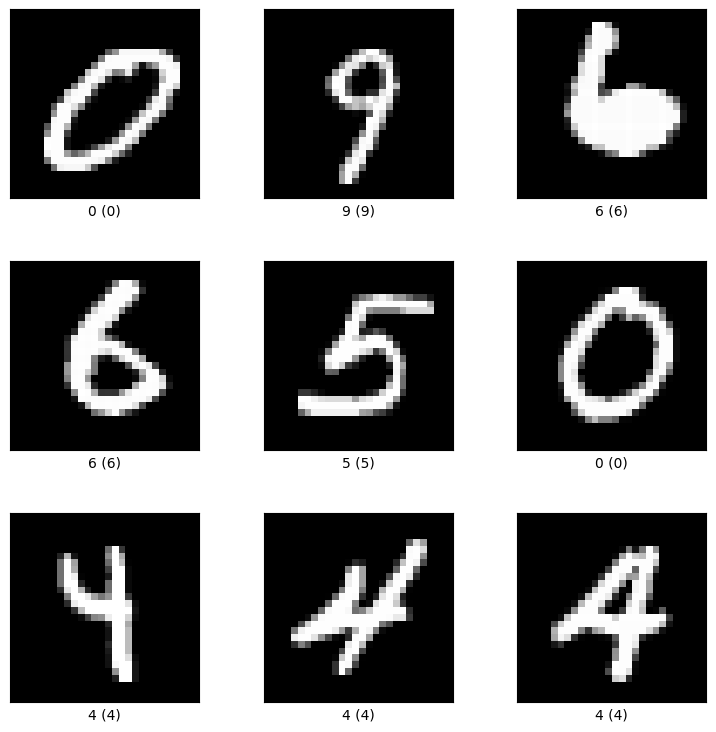

In [45]:
fig = tfds.show_examples(ds_val, ds_info)

In [46]:
ds_train.element_spec

(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [47]:
# one hot
#1 => 0 1 0 0 0 0 0 0 0 0
#7 => 0 0 0 0 0 0 0 1 0 0

In [48]:
def normalize_img(image,label ):
  return tf.cast(image, tf.float32) / 255., tf.one_hot(label,depth=10)


def data_load(data_ds,augmented=normalize_img,shuffle_=True ,batch_=5):
    data_ds = data_ds.map(
        augmented, num_parallel_calls=tf.data.AUTOTUNE)
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

In [49]:
data_train = data_load(ds_train)
data_test = data_load(ds_test,shuffle_=False)
data_val = data_load(ds_val,shuffle_=False)

In [50]:
data_val

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]], shape=(5, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)


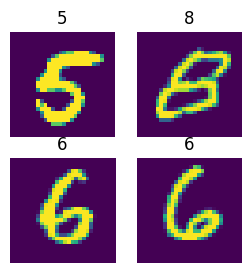

In [51]:
plt.figure(figsize=(3, 3))
i=0
for ds,lb in data_train.take(4):
    print(ds.shape,lb)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(ds[0].numpy())
    index = tf.argmax(lb, axis=1)
    plt.title('{}'.format(index[0].numpy()))
    plt.axis("off")
    i+=1

### Data Augmentation: https://www.tensorflow.org/guide/keras/preprocessing_layers

### Metodo 1. sobre tf.data

In [ ]:
def augment_data(images, labels):
    images = tf.image.random_flip_left_right(images)
    images = tf.image.random_flip_up_down(images)
    #images = tf.image.rot90(images)
    return images, labels

# datos[1,2]->modelo([1,2])->rta

#1epoca [1,2]
#2epoca [1,2f]
#3epoca [1f,2f]
#4epoca [1f,2]
#5epoca [1,2]

In [57]:
data_train = data_load(ds_train,augmented=augment_data)
data_test = data_load(ds_test,augmented=augment_data,shuffle_=False)

(5, 28, 28, 1) tf.Tensor([2 7 4 4 0], shape=(5,), dtype=int64)
(5, 28, 28, 1) tf.Tensor([5 0 8 7 5], shape=(5,), dtype=int64)
(5, 28, 28, 1) tf.Tensor([7 9 7 2 1], shape=(5,), dtype=int64)
(5, 28, 28, 1) tf.Tensor([0 7 3 4 4], shape=(5,), dtype=int64)


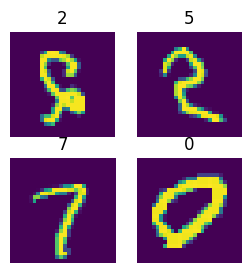

In [58]:
plt.figure(figsize=(3, 3))
i=0
for ds,lb in data_train.take(4):
    print(ds.shape,lb)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(ds[0].numpy())
    plt.title('{}'.format(lb[0].numpy()))
    plt.axis("off")
    i+=1

### Metodo 2. Usando Sequence en tf.data

In [59]:
from tensorflow.keras import layers, Sequential
trainAug = Sequential([
        layers.Rescaling(scale=1.0 / 255),
        layers.RandomContrast(0.5),
        layers.RandomZoom(.5, .2),
        layers.RandomFlip("horizontal"),
        layers.RandomCrop(20,20)
    ],name='augmentation_in_model')


layer_onehot = layers.CategoryEncoding(
          num_tokens=10, output_mode="one_hot")

In [60]:
def data_load_sequential(data_ds,shuffle_train=True ,batch_=5):
    data_ds = data_ds.map(
        lambda x, y: (trainAug(x,shuffle_train),layer_onehot(y)), num_parallel_calls=tf.data.AUTOTUNE)
    data_ds = data_ds.cache()
    if shuffle_train:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

data_train = data_load_sequential(ds_train)
data_test = data_load_sequential(ds_test,shuffle_train=False)

In [62]:
ds.shape

TensorShape([5, 20, 20, 1])

(5, 20, 20, 1) tf.Tensor(
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 20, 20, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 20, 20, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 20, 20, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)


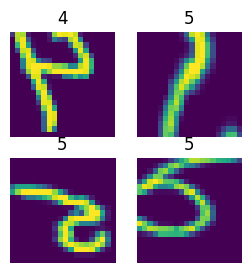

In [61]:
plt.figure(figsize=(3, 3))
i=0
for ds,lb in data_train.take(4):
    print(ds.shape,lb)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(ds[0].numpy())
    shaped=ds[0].numpy().shape
    index = tf.argmax(lb, axis=1)
    plt.title('{}'.format(index[0].numpy()))
    plt.axis("off")
    i+=1

### Metodo 3. Usando Sequence dentro del modelo

In [63]:
tf.keras.backend.clear_session()
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=shaped))
model.add(trainAug)
model.add(layers.Flatten())
model.add(layers.Dense(10,activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 augmentation_in_model (Seq  (20, 20, 1)               0         
 uential)                                                        
                                                                 
 flatten (Flatten)           (20, 400)                 0         
                                                                 
 dense (Dense)               (20, 10)                  4010      
                                                                 
Total params: 4010 (15.66 KB)
Trainable params: 4010 (15.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Analisis en Texto

In [67]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews", 
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True)

In [70]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(5)))
print(train_examples_batch,train_labels_batch)

tf.Tensor(
[b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
 b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot de

In [71]:
def tf_lower_and_split_punct(text):
  
  text = tf.strings.lower(text)
  text = tf.strings.regex_replace(text, '[^ a-z.?!,¿]', '')
  text = tf.strings.regex_replace(text, '[.?!,¿]', r' \0 ')
  text = tf.strings.strip(text)
  text = tf.strings.join(['[START]', text, '[END]'], separator=' ')
  return text

In [72]:
def data_load_txt(data_ds,shuffle_=True ,batch_=12):
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

BATCH=32
data_train = data_load_txt(train_data,batch_=BATCH)
data_test = data_load_txt(test_data,shuffle_=False,batch_=BATCH)
data_val = data_load_txt(validation_data,shuffle_=False,batch_=BATCH)

In [73]:
max_vocab_size = 10000

input_text_processor = tf.keras.layers.TextVectorization(
    standardize=tf_lower_and_split_punct,
    max_tokens=max_vocab_size)

In [74]:
reviews_only_ds = data_train.map(lambda a, b: a) 
input_text_processor.adapt(reviews_only_ds)

In [75]:
input_text_processor.get_vocabulary()[:10]

['', '[UNK]', 'the', '.', ',', 'and', 'a', 'of', 'to', 'is']

In [76]:
for idx in data_train.take(1):
    example_tokens = input_text_processor(idx[0])
    print(idx[1],example_tokens)

tf.Tensor([1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1], shape=(32,), dtype=int64) tf.Tensor(
[[  34   14   20 ...    0    0    0]
 [  34   95  281 ...    0    0    0]
 [  34   13  121 ...    0    0    0]
 ...
 [  34   19    2 ... 1400    3   35]
 [  34   18  458 ...    0    0    0]
 [  34  395   16 ...    0    0    0]], shape=(32, 1006), dtype=int64)


In [77]:
input_vocab = np.array(input_text_processor.get_vocabulary())
tokens = input_vocab[example_tokens[0].numpy()]
' '.join(tokens)

'[START] this movie is the first of miikes triad society trilogy , and the trilogy kicks of to a great start . the movies in the trilogy are only connected [UNK] , and these themes are actually apparent in all his films , if you look close enough . [UNK] triad society is about a cop trying to prevent his kid brother from getting too involved with a rather extreme gang of outsiders , struggling their way to the top of [UNK] [UNK] . the kid brother is a lawyer , and the triad gang is becoming increasingly in need of one , as the movie progresses . the movie takes place in a very harsh environment , and is therefore pretty violent and tough . miike has done worse , but since this is a serious movie it hits you very hard . as usual there is also a lot of perverted sex , mostly homosexual in this one . the movie is in many ways a typical gangster movie , but with a great drive and true [UNK] . if youve only seen miikes [UNK] movies [UNK] the killer , [UNK] etc . this is worth checking out s

Text(0.5, 1.0, 'Mask')

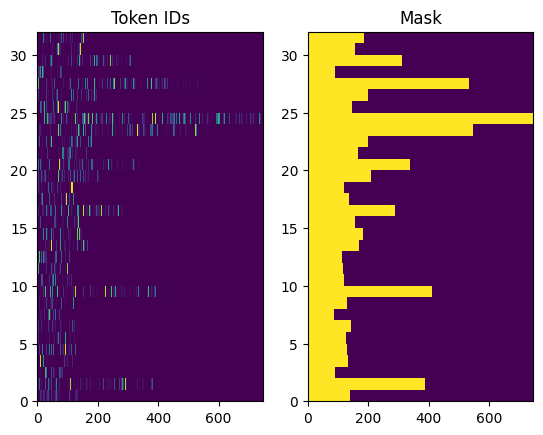

In [54]:
plt.subplot(1, 2, 1)
plt.pcolormesh(example_tokens)
plt.title('Token IDs')

plt.subplot(1, 2, 2)
plt.pcolormesh(example_tokens != 0)
plt.title('Mask')

In [55]:
from tensorflow.keras.layers import Embedding,Dense
from tensorflow.keras import Sequential

vocab_size = 10000
embedding_dim=16

model = Sequential([
input_text_processor,
  Embedding(input_dim = vocab_size, 
            output_dim = embedding_dim, 
            name="embedding"),
   Dense(1)])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, None)              0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, None, 16)          160000    
                                                                 
 dense_1 (Dense)             (None, None, 1)           17        
                                                                 
Total params: 160017 (625.07 KB)
Trainable params: 160017 (625.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [78]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  r"C:\Users\javier\Documents\2025_nn\introduction_neural_networks\imagenes",
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(212, 212),
  batch_size=2)


Found 5 files belonging to 2 classes.
Using 4 files for training.


In [81]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 212, 212, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>